In [1]:
# Environment Variables

import os
import sys

sys.path.append(os.path.abspath(".."))

YES = 1
NO = 0

using_GPU = NO
BACKEND = "Vivado"

In [2]:
# Imports

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import hls4ml
import tensorflow as tf
from qkeras import QConv2DBatchnorm, QActivation, QDense
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
# import src.utils as utils     #! currently does not work
from qkeras.utils import _add_supported_quantized_objects

%matplotlib inline
if using_GPU:
    print(tf.config.list_physical_devices("GPU"))

2026-09-22 05:57:40.319245: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-22 05:57:40.526173: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/aya/local_libs:
2026-09-22 05:57:40.526225: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-09-22 05:57:41.595302: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared obje

In [3]:
# Global Constants

DATA_DIR = "data/"
SRC_DIR = "src/"

RANDOM_SEED = 23
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

IMAGE_X_DIM = 48
IMAGE_Y_DIM = 48

CENTER_X = IMAGE_X_DIM // 2
MIN_CENTER_X = -5
MAX_CENTER_X = 5

CENTER_Y = IMAGE_Y_DIM // 2
MIN_CENTER_Y = -5
MAX_CENTER_Y = 5

MIN_STD_X = 5
MAX_STD_X = 15

MIN_STD_Y = 5
MAX_STD_Y = 15

MIN_THETA = 0
MAX_THETA = np.pi

MIN_INTENSITY = 0.05
MAX_INTENSITY = 0.7

scaling_arr = tf.constant([IMAGE_X_DIM, IMAGE_Y_DIM, IMAGE_X_DIM // 2, IMAGE_X_DIM // 2, MAX_THETA / 2])

2026-09-22 05:57:43.280624: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/aya/local_libs:
2026-09-22 05:57:43.280674: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2026-09-22 05:57:43.280703: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (hvm1): /proc/driver/nvidia/version does not exist
2026-09-22 05:57:43.281361: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Util Functions

def gaussian_gen(
    center_x: int, center_y: int, std_x: int, std_y: int, theta: float
) -> np.ndarray:
    X = np.arange(0, IMAGE_X_DIM, 1)
    Y = np.arange(0, IMAGE_Y_DIM, 1)
    X, Y = np.meshgrid(X, Y)

    cos_theta_sqrd = np.power(np.cos(theta), 2)
    sin_theta_sqrd = np.power(np.sin(theta), 2)
    sin_cos_theta = np.sin(theta) * np.cos(theta)

    std_x_sqrd = np.power(std_x, 2)
    std_y_sqrd = np.power(std_y, 2)

    a = (cos_theta_sqrd) / (2 * std_x_sqrd) + (sin_theta_sqrd) / (2 * std_y_sqrd)
    b = -1 * (sin_cos_theta) / (2 * std_x_sqrd) + (sin_cos_theta) / (2 * std_y_sqrd)
    c = (sin_theta_sqrd) / (2 * std_x_sqrd) + (cos_theta_sqrd) / (2 * std_y_sqrd)

    gaussian = np.exp(
        -(
            a * (X - center_x) ** 2
            + 2 * b * (X - center_x) * (Y - center_y)
            + c * (Y - center_y) ** 2
        )
    )

    return np.expand_dims(gaussian, -1)


def gaussian_img_gen(VERBOSE: bool = False) -> tuple:
    # Randomize params
    center_x = CENTER_X + np.random.randint(low=MIN_CENTER_X, high=MAX_CENTER_X)
    center_y = CENTER_Y + np.random.randint(low=MIN_CENTER_Y, high=MAX_CENTER_Y)

    std_x = np.random.randint(low=MIN_STD_X, high=MAX_STD_X)
    std_y = np.random.randint(low=MIN_STD_Y, high=MAX_STD_Y)
    theta = np.random.uniform(low=MIN_THETA, high=MAX_THETA)

    intensity = np.random.uniform(low=MIN_INTENSITY, high=MAX_INTENSITY)

    # Generate Gaussian
    params = (center_x, center_y, std_x, std_y, theta)
    gaussian = gaussian_gen(center_x, center_y, std_x, std_y, theta) * intensity

    # Convert to 8 bit int
    img = gaussian
    # img = (gaussian * 255)

    # DEBUG
    if VERBOSE:
        # print(f"[Image Shape]: {str(img.shape)}")
        # print(f"[Label Shape]: {str(label.shape)}")
        pass
    return (img, params)

In [5]:
# Functions: (TENSORFLOW)

# mean_x, mean_y, cov_x, cov_y, theta
def generate_guassian(batch, image_shape):
    batch_size = batch.shape[0]
    batch = tf.expand_dims(tf.expand_dims(batch, axis=-1), axis=-1)
    x0, y0, sigma_x, sigma_y, theta = tf.cast(tf.unstack(batch, axis=-3), tf.float32)

    x_range = tf.range(start=0, limit=image_shape[0], delta=1)
    y_range = tf.range(start=0, limit=image_shape[1], delta=1)
    X_coord, Y_coord = tf.meshgrid(x_range, y_range, indexing="xy")
    X_coord = tf.cast(tf.expand_dims(X_coord, axis=0), tf.float32)
    Y_coord = tf.cast(tf.expand_dims(Y_coord, axis=0), tf.float32)

    X_coord = tf.tile(X_coord, [batch_size, 1, 1])
    Y_coord = tf.tile(Y_coord, [batch_size, 1, 1])

    a = tf.math.pow(tf.math.cos(theta), 2) / (
        2 * tf.math.pow(sigma_x, 2)
    ) + tf.math.pow(tf.math.sin(theta), 2) / (2 * tf.math.pow(sigma_y, 2))
    b = -1 * tf.math.sin(theta) * tf.math.cos(theta) / (
        2 * tf.math.pow(sigma_x, 2)
    ) + tf.math.sin(theta) * tf.math.cos(theta) / (2 * tf.math.pow(sigma_y, 2))
    c = tf.math.pow(tf.math.sin(theta), 2) / (
        2 * tf.math.pow(sigma_x, 2)
    ) + tf.math.pow(tf.math.cos(theta), 2) / (2 * tf.math.pow(sigma_y, 2))

    img = tf.exp(
        -1
        * (
            a * (X_coord - x0) ** 2
            + 2 * b * (X_coord - x0) * (Y_coord - y0)
            + c * (Y_coord - y0) ** 2
        )
    )

    if using_GPU:
        return tf.expand_dims(img, axis=-1)  # if (batch_size, height, width, channels)
    
    return tf.expand_dims(img, axis=1)  # if (batch_size, channels, height, width)

def pp_weighted_mse_loss(I, J, n): # TODO: replace I, J, n names
    W = tf.pow(I, n)

    squared_diffs = tf.pow(I - J, 2)

    weighted_squared_diffs = W * squared_diffs

    loss = tf.reduce_mean(weighted_squared_diffs)

    return loss

def dice_loss(y_true, y_pred, delta=0.5):

    weights = tf.constant([3.0, 1.0, 2.0, 2.0, 0.1], dtype=tf.float32)
    y_pred = y_pred + 1e-8
    diff = y_true - y_pred
    abs_diff = tf.abs(diff)

    quadratic = tf.minimum(abs_diff, delta)
    linear = abs_diff - quadratic
    huber_loss = 0.5 * tf.square(quadratic) + delta * linear

    weighted_loss = weights * huber_loss
    return tf.reduce_mean(weighted_loss)

In [6]:
# Generate Data
SAMPLES_TO_CREATE = 10000


def process_image():
    (
        img,
        label,
    ) = gaussian_img_gen()
    return img, label


img_arr = []
label_arr = []
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_image) for _ in range(SAMPLES_TO_CREATE)]
    for future in tqdm(as_completed(futures), total=SAMPLES_TO_CREATE):
        img, label = future.result()
        img_arr.append(
            # np.round(img / (np.max(img) - 1) * 256) / 256
            np.round(img / (np.max(img)) * 255) / 256
        )  # Normalize values to [0, 1)
        label_arr.append(label)

img_arr = np.array(img_arr)
label_arr = np.array(label_arr)

if using_GPU:
    img_arr = img_arr.reshape(SAMPLES_TO_CREATE, 1, IMAGE_Y_DIM, IMAGE_X_DIM)

print(f"[Images Shape]: {img_arr.shape}")
print(f"[Labels Shape]: {label_arr.shape}")

100%|██████████| 10000/10000 [00:03<00:00, 2966.61it/s]


[Images Shape]: (10000, 48, 48, 1)
[Labels Shape]: (10000, 5)


In [7]:
# Convert Data to tf DataSet
BATCH_SIZE = 50

dataset = tf.data.Dataset.from_tensor_slices((img_arr, label_arr))
dataset = dataset.shuffle(SAMPLES_TO_CREATE, reshuffle_each_iteration=True)
dataset = dataset.batch(BATCH_SIZE)

In [8]:
# Model Architecture
TOTAL_BITS        = 8
INTEGER_FIRST     = 0   
INTEGER_REST      = 2  
L1_REG            = 1e-4

model = tf.keras.Sequential(
    [
        QConv2DBatchnorm(
            input_shape=(IMAGE_Y_DIM, IMAGE_X_DIM, 1),
            filters=6, kernel_size=3, strides=1, padding="valid",
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_FIRST},alpha=1)",
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_FIRST},alpha=1)",
            kernel_initializer="lecun_uniform",
            kernel_regularizer=tf.keras.regularizers.l1(L1_REG),
            use_bias=True,
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"),
            tf.keras.layers.MaxPool2D(pool_size=4, strides=4
        ),

        QConv2DBatchnorm(
            filters=8, kernel_size=3, strides=1, padding="valid",
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)",
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)",
            kernel_initializer="lecun_uniform",
            kernel_regularizer=tf.keras.regularizers.l1(L1_REG),
            use_bias=True,
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"),
            tf.keras.layers.MaxPool2D(pool_size=2, strides=2
        ),

        QConv2DBatchnorm(
            filters=10, kernel_size=3, strides=1, padding="valid",
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)",
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)",
            kernel_initializer="lecun_uniform",
            kernel_regularizer=tf.keras.regularizers.l1(L1_REG),
            use_bias=True,
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"),
            tf.keras.layers.MaxPool2D(pool_size=2, strides=2
        ),

        tf.keras.layers.Flatten(),

        QDense(units=15, 
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)", 
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)"
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"
        ),

        QDense(
            units=10, 
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)", 
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)"
        ),

        QActivation(
            f"quantized_relu({TOTAL_BITS}, {INTEGER_REST})"
        ),

        QDense(units=5 , 
            kernel_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)", 
            bias_quantizer=f"quantized_bits({TOTAL_BITS},{INTEGER_REST},alpha=1)"
        ),
    ],
    name="pp_model"
)

model.compile(optimizer="adam", loss=dice_loss, run_eagerly=True)
model.summary()

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089
Model: "pp_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 q_conv2d_batchnorm (QConv2D  (None, 46, 46, 6)        85        
 Batchnorm)                                                      
                                                                 
 q_activation (QActivation)  (None, 46, 46, 6)         0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 11, 11, 6)        0         
 )                                                               
                                                                 
 q_conv2d_batchnorm_1 (QConv  (None, 9, 9, 8)          473       
 2DBatchnorm)                                          

In [9]:
# Training Loop 
#! TF DType 8bit throughout?
TRAIN_MODEL = NO
SAVE_MODEL = NO
LOAD_MODEL = YES
NUM_EPOCHS = 500
MODEL_PATH = "../Models/"
MODEL_NAME = "gaussian_nov24.keras"


if TRAIN_MODEL:

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.01,
        decay_steps=NUM_EPOCHS,
        decay_rate=0.9)
    
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
        
    loss_arr = []
    for epoch in range(NUM_EPOCHS):
        running_loss = 0.0

        for batch in tqdm(dataset): 
            image_batch = tf.cast(batch[0], tf.float32)
            label_batch = tf.cast(batch[1], tf.float32)
            with tf.GradientTape() as tape:
                embedding = model(image_batch) * scaling_arr

                loss = dice_loss(label_batch, embedding)
            grads = tape.gradient(loss, model.trainable_variables)
            adam_optimizer.apply_gradients(zip(grads, model.trainable_variables))

            running_loss += loss.numpy()
        average_loss = running_loss / len(dataset)
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {average_loss}")
        loss_arr.append(average_loss)
    loss_arr = np.array(loss_arr)

co = {}
_add_supported_quantized_objects(co)
# Add any custom losses
co["dice_loss"] = dice_loss

if SAVE_MODEL:
    model.save(f'{MODEL_PATH}{MODEL_NAME}')

if LOAD_MODEL:
    model = tf.keras.models.load_model(f'{MODEL_PATH}{MODEL_NAME}', custom_objects=co)

# model.summary()

In [10]:
validation_gaussian_image = []
validation_gaussian_label = []
for i in range(BATCH_SIZE):
    img, label = gaussian_img_gen()
    img = np.round(img / (np.max(img)) * 255) / 256
    validation_gaussian_image.append(img)
    validation_gaussian_label.append(label)
 
predicted_params = model.predict(tf.cast(validation_gaussian_image, tf.float32)) * scaling_arr
reconstructed_images = generate_guassian(predicted_params, (48,48))

2/2 [==============================] - 1s 8ms/step


(27, 25, 10, 10, 1.9711397480247905)
tf.Tensor([27.46875  23.34375  10.300781 10.300781  1.517874], shape=(5,), dtype=float32)


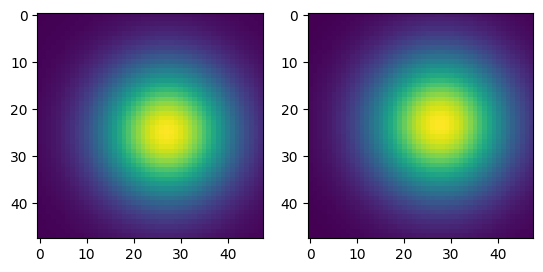

In [11]:
# View (MSE / MAE is not great because fitting is not great)
index = np.random.randint(low=0, high=BATCH_SIZE)

plt.subplot(1, 2, 1)
plt.imshow(np.squeeze(validation_gaussian_image[index]))

plt.subplot(1, 2, 2)
plt.imshow(np.squeeze(reconstructed_images[index]))

print(validation_gaussian_label[index])
print(predicted_params[index])

In [12]:
config = hls4ml.utils.config_from_keras_model(
    model,
    granularity='name',
    # backend='Vitis', # new version of hls4ml doesn't use backend arument in config_from keras_model
                       # instead it uses the backend argument in the convert_from_keras_model function
    default_precision='fixed<32,16>',
    default_reuse_factor=32,
)

config['Model']['Trace'] = True
config['Model']['Strategy'] = 'Resource'
config['Model']['ReuseFactor'] = 16
config['Model']['Precision'] = 'ap_fixed<16,6>'  # 16,6
config['IOType'] = 'io_stream'

config['LayerName'] = {
    # --- Input ---
    'q_conv2d_batchnorm_input': {
        'Precision': {'result': 'ap_ufixed<8,0>'},  # mono8 input
        'Trace': True
    },

    # --- Block 1 ---
    'q_conv2d_batchnorm': {
        'Precision': {
            'weight': 'ap_fixed<8,1>', 
            'bias':   'ap_fixed<8,1>',
            'result': 'ap_fixed<8,3>'
        },
        'ReuseFactor': 9,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT',
        'Trace': True
    },
    'q_activation': {
        'Precision': {'result': 'ap_ufixed<8,2>'},  
        'ReuseFactor': 8,
        'Trace': True
    },
    'max_pooling2d': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 1,
        'Trace': True
    },

    # --- Block 2 ---
    'q_conv2d_batchnorm_1': {
        'Precision': {
            'weight': 'ap_fixed<8,3>',
            'bias':   'ap_fixed<8,3>',
            'result': 'ap_fixed<8,3>'
        },
        'ReuseFactor': 9,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT',
        'Trace': True
    },
    'q_activation_1': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 8,
        'Trace': True
    },
    'max_pooling2d_1': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 1,
        'Trace': True
    },

    # --- Block 3 ---
    'q_conv2d_batchnorm_2': {
        'Precision': {
            'weight': 'ap_fixed<8,3>',
            'bias':   'ap_fixed<8,3>',
            'result': 'ap_fixed<8,3>'
        },
        'ReuseFactor': 8,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT',
        'Trace': True
    },
    'q_activation_2': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 8,
        'Trace': True
    },
    'max_pooling2d_2': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 1,
        'Trace': True
    },

    # --- Flatten ---
    'flatten': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'Trace': True
    },

    # --- Dense 15 ---
    'q_dense': {
        'Precision': {
            'weight': 'ap_fixed<8,3>',
            'bias':   'ap_fixed<8,3>',
            'result': 'ap_fixed<8,3>'
        },
        'ReuseFactor': 10,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT',
        'Trace': True
    },
    'q_activation_3': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 16,
        'Trace': True
    },

    # --- Dense 10 ---
    'q_dense_1': {
        'Precision': {
            'weight': 'ap_fixed<8,3>',
            'bias':   'ap_fixed<8,3>',
            'result': 'ap_fixed<8,3>'
        },
        'ReuseFactor': 15,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT',
        'Trace': True
    },
    'q_activation_4': {
        'Precision': {'result': 'ap_ufixed<8,2>'},
        'ReuseFactor': 16,
        'Trace': True
    },

    # --- Dense 5 ---
    'q_dense_2': {
        'Precision': {
            'weight': 'ap_fixed<8,3>',
            'bias':   'ap_fixed<8,3>',
            'result': 'ap_fixed<8,3>'   
        },
        'ReuseFactor': 10,
        'RoundingMode': 'AP_RND',
        'SaturationMode': 'AP_SAT',
        'Trace': True
    },
}


In [13]:
if BACKEND=="Vivado":
    output_dir = f"src/hdl/RHEED_Gaussian/hls4ml/gaussian_new_hls4ml_prj"
elif BACKEND=="Vitis":
    output_dir = f"src/hdl/RHEED_Gaussian/hls4ml/gaussian_new_hls4ml_prj"
else: raise NotImplementedError

import shutil
shutil.rmtree(output_dir, ignore_errors=True)
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config, 
    output_dir=output_dir, 
    backend=BACKEND,
    part='xcku035-fbva676-2-e', 
    io_type="io_stream"
)
#  xc7vx690tffg1761-2
# 'xcku035-fbva676-2-e' # original

hls_model.compile() # hls_model.write for Windows 

print("")
print(hls_model.config.config['OutputDir'])



src/hdl/RHEED_Gaussian/hls4ml/gaussian_new_hls4ml_prj


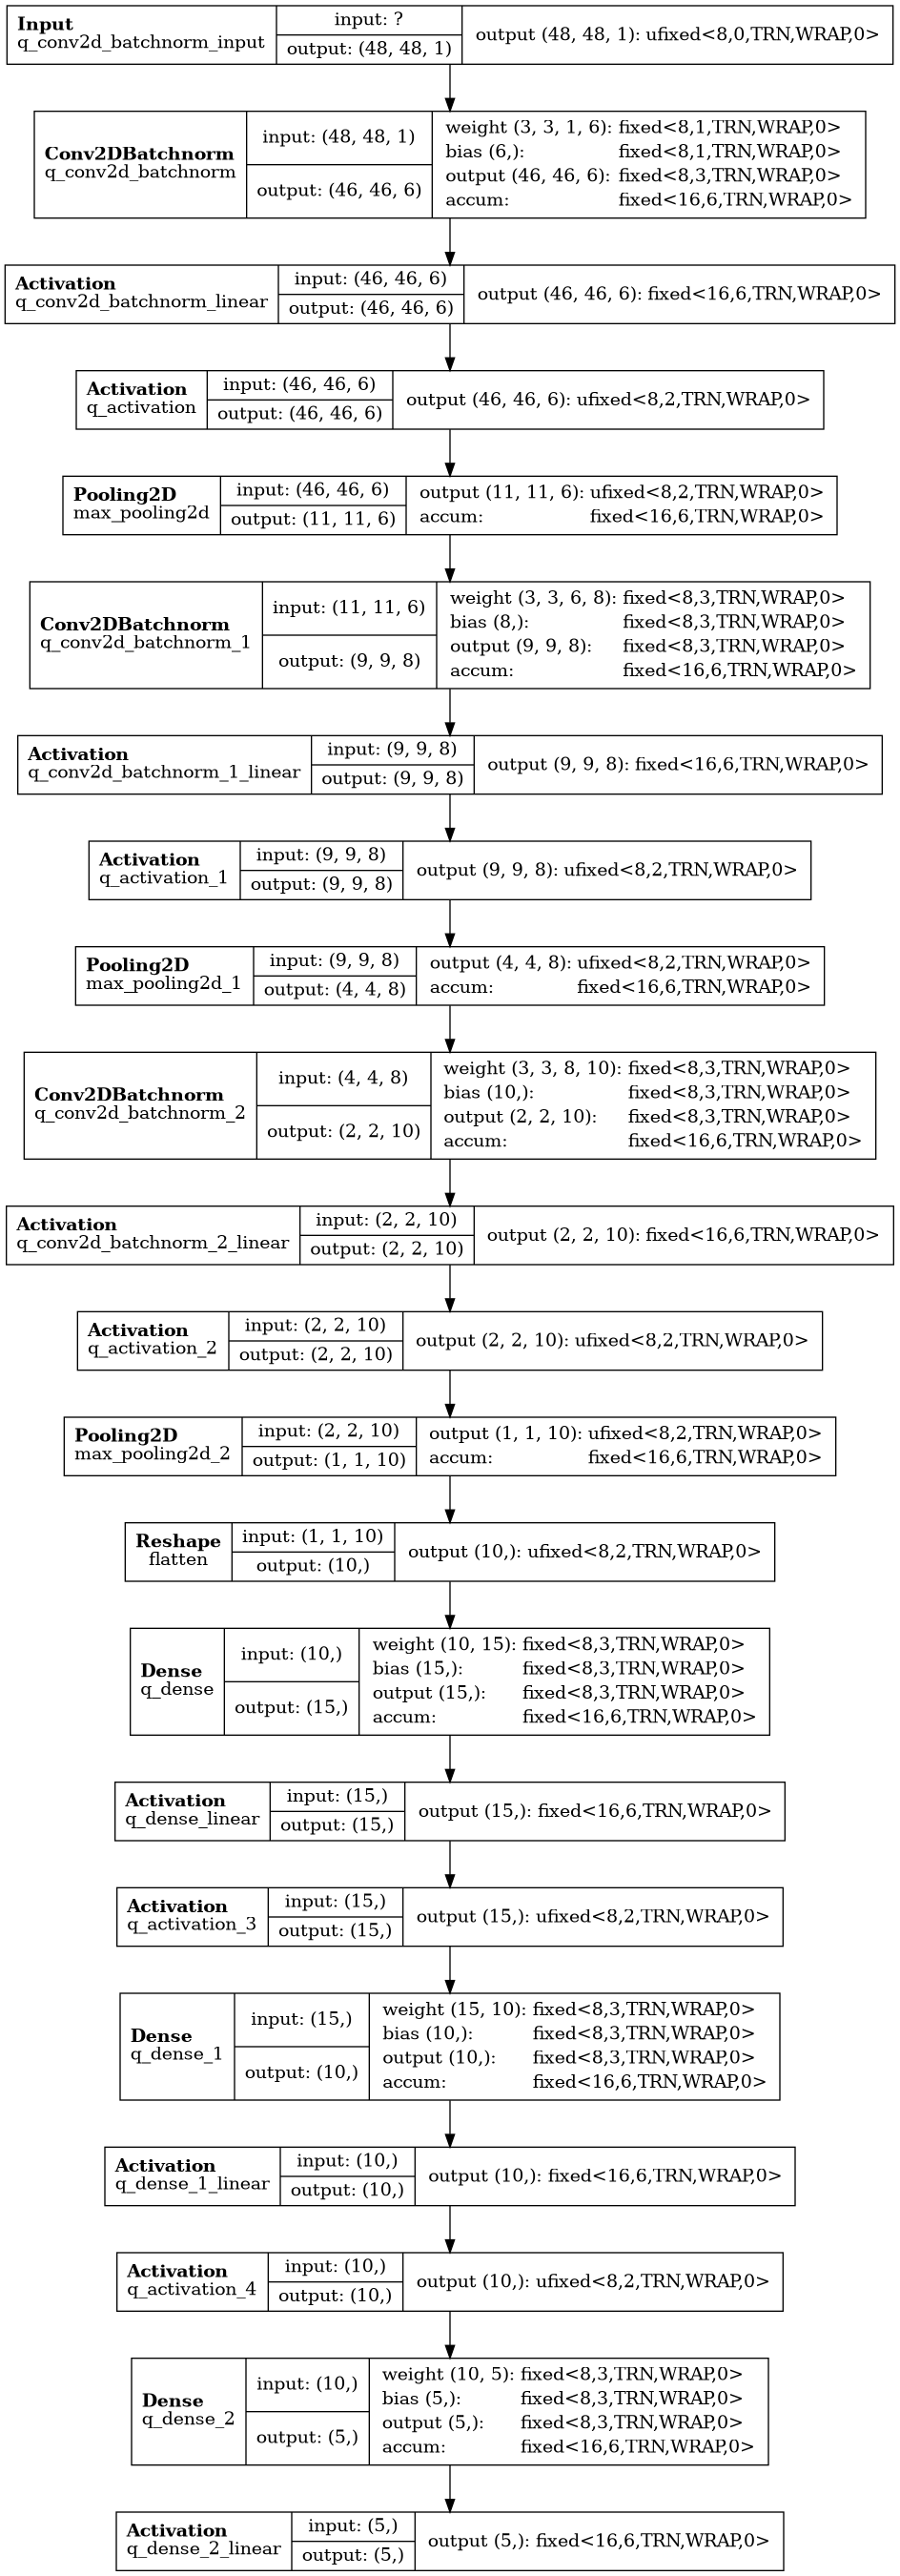

In [14]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [15]:
validation_gaussian_image = []
validation_gaussian_label = []
for i in range(BATCH_SIZE):
    img, label = gaussian_img_gen()
    img = np.round(img / (np.max(img)) * 255) / 256
    validation_gaussian_image.append(img)
    validation_gaussian_label.append(label)

predicted_params_keras = model.predict(tf.cast(validation_gaussian_image, tf.float32)) * scaling_arr
predicted_params_hls = hls_model.predict(np.array(validation_gaussian_image, dtype=np.float32)) * scaling_arr
reconstructed_images_keras = generate_guassian(predicted_params_keras, (48,48))
reconstructed_images_hls = generate_guassian(predicted_params_hls, (48,48))

2/2 [==============================] - 0s 7ms/step


(27, 28, 5, 5, 0.46320974326157566)
tf.Tensor([26.835938  23.90625    5.3554688  5.3554688  1.5562235], shape=(5,), dtype=float32)
tf.Tensor([22.5       24.         3.75       3.75       1.5707964], shape=(5,), dtype=float32)


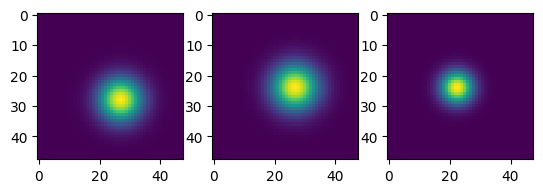

In [16]:
# View (MSE / MAE is not great because fitting is not great)
index = np.random.randint(low=0, high=BATCH_SIZE)

plt.subplot(1, 3, 1)
plt.imshow(np.squeeze(validation_gaussian_image[index]))

plt.subplot(1, 3, 2)
plt.imshow(np.squeeze(reconstructed_images_keras[index]))

plt.subplot(1, 3, 3)
plt.imshow(np.squeeze(reconstructed_images_hls[index]))


print(validation_gaussian_label[index])
print(predicted_params_keras[index])
print(predicted_params_hls[index])

In [17]:
hls_model.config.config

{'OutputDir': 'src/hdl/RHEED_Gaussian/hls4ml/gaussian_new_hls4ml_prj',
 'ProjectName': 'myproject',
 'Backend': 'Vivado',
 'Version': '1.0.0',
 'Part': 'xcku035-fbva676-2-e',
 'ClockPeriod': 5,
 'ClockUncertainty': '12.5%',
 'IOType': 'io_stream',
 'HLSConfig': {'Model': {'Precision': 'ap_fixed<16,6>',
   'ReuseFactor': 16,
   'Strategy': 'Resource',
   'BramFactor': 1000000000,
   'TraceOutput': False,
   'Trace': True,
   'BitExact': None},
  'LayerName': {'q_conv2d_batchnorm_input': {'Precision': {'result': 'ap_ufixed<8,0>'},
    'Trace': True},
   'q_conv2d_batchnorm': {'Precision': {'weight': 'ap_fixed<8,1>',
     'bias': 'ap_fixed<8,1>',
     'result': 'ap_fixed<8,3>'},
    'ReuseFactor': 9,
    'RoundingMode': 'AP_RND',
    'SaturationMode': 'AP_SAT',
    'Trace': True},
   'q_activation': {'Precision': {'result': 'ap_ufixed<8,2>'},
    'ReuseFactor': 8,
    'Trace': True},
   'max_pooling2d': {'Precision': {'result': 'ap_ufixed<8,2>'},
    'ReuseFactor': 1,
    'Trace': True},


In [ ]:
hls_model.build(csim=False, synth=True, vsynth=True, export=True)


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2019.1 (64-bit)
  **** SW Build 2552052 on Fri May 24 14:47:09 MDT 2019
  **** IP Build 2548770 on Fri May 24 18:01:18 MDT 2019
    ** Copyright 1986-2019 Xilinx, Inc. All Rights Reserved.

source /tools/Disk_Xilinx/Vivado/2019.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Disk_Xilinx/Vivado/2019.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'aya' on host 'hvm1' (Linux_x86_64 version 5.15.0-190-generic) on Tue Sep 22 05:58:41 PDT 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/src/hdl/RHEED_Gaussian/hls4ml/gaussian_new_hls4ml_prj'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Creating and opening project '/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/src/hdl/RHEED_Gaussian/hls4ml/gaussian_new_hls4ml_prj/myproject_prj'.
INFO: [HLS 200-10] Adding design file 'firmw

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '4.375',
  'BestLatency': '34571',
  'WorstLatency': '34577',
  'IntervalMin': '6914',
  'IntervalMax': '34562',
  'BRAM_18K': '120',
  'DSP': '0',
  'FF': '17010',
  'LUT': '46634',
  'URAM': '0',
  'AvailableBRAM_18K': '1080',
  'AvailableDSP': '1700',
  'AvailableFF': '406256',
  'AvailableLUT': '203128',
  'AvailableURAM': '0'},
 'VivadoSynthReport': {'LUT': '24707',
  'FF': '15649',
  'BRAM_18K': '46',
  'DSP48E': '0'}}

In [26]:
hls4ml.report.read_vivado_report(hls_model.config.config['OutputDir'])

Found 1 solution(s) in src/hdl/RHEED_Gaussian/hls4ml/gaussian_new_hls4ml_prj/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vivado HLS Report for 'myproject'
* Date:           Tue Sep 22 06:03:12 2026

* Version:        2019.1 (Build 2552052 on Fri May 24 15:28:33 MDT 2019)
* Project:        myproject_prj
* Solution:       solution1
* Product family: kintexu
* Target device:  xcku035-fbva676-2-e


== Performance Estimates
+ Timing (ns): 
    * Summary: 
    +--------+-------+----------+------------+
    |  Clock | Target| Estimated| Uncertainty|
    +--------+-------+----------+------------+
    |ap_clk  |   5.00|     4.375|        0.62|
    +--------+-------+----------+------------+

+ Latency (clock cycles): 
    * Summary: 
    +-------+-------+------+-------+----------+
    |    Latency    |   Interval   | Pipeline |
    |  min  |  max  |  min |  max  |   Type   |
    +-------+-------+------+-------+----------+
    |  34571|  3

In [20]:
# --- one-hot test generation  ---
import numpy as np, os
import math

# Rounding half up matches Xilinx's AP_RND rounding convention (different from np.round())
def round_half_up(x):
    return math.floor(x + 0.5) if x >= 0 else math.ceil(x - 0.5)

def dec_to_bin(number : int | float, bits=-1):
    """
    Converts a decimal number to a str binary representation
    
    :param number: Number to convert into binary
    :type number: int | float
    :param bits: Bitwidth of output number. If negative, uses the minimum amount
    """
    # Determines if a number is negative
    neg=False
    if (number<0):
        number*=-1
        number-=1
        neg=True
    
    # Rounds number up to nearest int
    number=int(round_half_up(number)) # instead of np.round()
    out=""

    # Return maximum positive or negative number if the input cannot be represented by the bitwidth
    if (bits>0 and neg==False and number>2**(bits-1)-1):
        return "0" + "1"*(bits-1)
    elif (bits>0 and neg==True and number>=2**(bits-1)):
        return "1" + "0"*(bits-1)
    
    # Do typical conversion of decimal to binary number
    while (number>0):
        res = number%2
        if (neg):
            res= 0 if (res==1) else 1
        out=f"{res}{out}"
        if (len(out)==(bits-1)):
            break
        number=int(number/2)
        
    # Add signed bit
    if (neg):
        out=f"{1}{out}"
    else: out=f"{0}{out}"

    # If the number was 0
    if (len(out)==0):
        out="0"

    # Sign extension
    while (len(out)<bits):
        out=f"{out[0]}{out}"

    return out

def gen_one_hot_test_data(image_dim=48, out_dir="gaussian_test_data", nfrac=7, width=8):
    os.makedirs(out_dir, exist_ok=True)
    # positions to insert a one-hot value
    positions = [(0,0), (image_dim-1, image_dim-1), (image_dim//2, image_dim//2),
                 (0, image_dim//2), (image_dim//2, 0)]
    samples = []
    # for each position, build a 48x48x1 array of zeros, then
    # set exactly one pixel to 1.0
    for idx, (y, x) in enumerate(positions):
        img = np.zeros((image_dim, image_dim, 1), dtype=np.float32)
        img[y, x, 0] = 225/226
        samples.append(img)
        # save raw float image
        np.save(os.path.join(out_dir, f"onehot_{idx}_y{y}_x{x}.npy"), img)

        # -- used for handmade RTL testbench ----
        # turn the 48x48x1 array into a single 1D list (row-major)
        flat = img.flatten()
        # for each pixel, multiply by 2^NFRAC to quantize
        with open(os.path.join(out_dir, f"onehot_{idx}_y{y}_x{x}.txt"), "w") as f:
            for val in flat:
                f.write(dec_to_bin(round(val * (2**nfrac)), width) + "\n")
    return samples, positions

samples, positions = gen_one_hot_test_data(nfrac=7)  # NFRAC=7 matches current NFRAC_first for input layer

In [21]:
# For generating populated (no longer one-hot) test images
# Returns samples (generated image) and labels represeting the gaussian parameters
# used to create the image
def gen_populated_test_images(n_samples=3, out_dir="/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/gaussian_test_data", nfrac=7, width=8):
    os.makedirs(out_dir, exist_ok=True)
    samples = []
    labels = []
    for idx in range(n_samples):
        img, params = gaussian_img_gen()
        img_norm = np.round(img / np.max(img) * 255) / 256  # same normalization as real training data
        samples.append(img_norm)
        labels.append(params)

        np.save(os.path.join(out_dir, f"populated_{idx}.npy"), img_norm)

        flat = img_norm.flatten()
        with open(os.path.join(out_dir, f"populated_{idx}.txt"), "w") as f:
            for val in flat:
                f.write(dec_to_bin(round(float(val) * (2**nfrac)), width) + "\n")
        print(f"sample {idx}: params={params}")
    return samples, labels

samples, labels = gen_populated_test_images(n_samples=15)

sample 0: params=(27, 20, 5, 8, 2.30649909487897)
sample 1: params=(24, 21, 14, 11, 0.267507216584715)
sample 2: params=(25, 23, 14, 10, 0.5863116329650928)
sample 3: params=(21, 27, 11, 8, 2.5336186730161807)
sample 4: params=(20, 20, 13, 14, 2.7014084841158827)
sample 5: params=(28, 21, 8, 9, 0.24072683296576888)
sample 6: params=(26, 24, 8, 7, 0.983912458345541)
sample 7: params=(26, 27, 5, 5, 3.012815368790352)
sample 8: params=(20, 21, 8, 7, 0.6681264535628446)
sample 9: params=(20, 19, 12, 10, 1.1128764421674395)
sample 10: params=(26, 27, 12, 11, 0.27036141243640305)
sample 11: params=(24, 24, 8, 12, 1.0840083327258054)
sample 12: params=(20, 24, 11, 8, 2.623408382762854)
sample 13: params=(25, 26, 9, 5, 3.019743568693508)
sample 14: params=(20, 22, 7, 9, 0.5679783051811378)


In [22]:
from hls4ml.model.profiling import get_ymodel_keras

for idx in range(15):
    X_test = samples[idx][np.newaxis, ...].astype(np.float32)
    hls4ml_pred, hls4ml_trace = hls_model.trace(X_test)
    keras_trace = get_ymodel_keras(model, X_test)

    for layer_name, values in hls4ml_trace.items():
        np.savetxt(f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/traces/hls4ml_populated{idx}_{layer_name}.csv", np.array(values).flatten(), delimiter=',')
    for layer_name, values in keras_trace.items():
        np.savetxt(f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/traces/keras_populated{idx}_{layer_name}.csv", np.array(values).flatten(), delimiter=',')
    print(f"traced populated{idx}")

Recompiling myproject with tracing
1/1 [==============================] - 1s 889ms/step
Done taking outputs for Keras model.
traced populated0
Recompiling myproject with tracing
1/1 [==============================] - 1s 890ms/step
Done taking outputs for Keras model.
traced populated1
Recompiling myproject with tracing
1/1 [==============================] - 1s 1s/step
Done taking outputs for Keras model.
traced populated2
Recompiling myproject with tracing


1/1 [==============================] - 1s 805ms/step
Done taking outputs for Keras model.
traced populated3
Recompiling myproject with tracing


1/1 [==============================] - 1s 866ms/step
Done taking outputs for Keras model.
traced populated4
Recompiling myproject with tracing
1/1 [==============================] - 1s 818ms/step
Done taking outputs for Keras model.
traced populated5
Recompiling myproject with tracing
1/1 [==============================] - 1s 831ms/step
Done taking outputs for Keras model.
traced populated6
Recompiling myproject with tracing
1/1 [==============================] - 1s 846ms/step
Done taking outputs for Keras model.
traced populated7
Recompiling myproject with tracing
1/1 [==============================] - 1s 876ms/step
Done taking outputs for Keras model.
traced populated8
Recompiling myproject with tracing
1/1 [==============================] - 1s 837ms/step
Done taking outputs for Keras model.
traced populated9
Recompiling myproject with tracing
1/1 [==============================] - 1s 824ms/step
Done taking outputs for Keras model.
traced populated10
Recompiling myproject with tracin

In [27]:
print(config['Model'].get('ClockPeriod'))

None


In [28]:
print(hls_model.config.config)

{'OutputDir': 'src/hdl/RHEED_Gaussian/hls4ml/gaussian_new_hls4ml_prj', 'ProjectName': 'myproject', 'Backend': 'Vivado', 'Version': '1.0.0', 'Part': 'xcku035-fbva676-2-e', 'ClockPeriod': 5, 'ClockUncertainty': '12.5%', 'IOType': 'io_stream', 'HLSConfig': {'Model': {'Precision': 'ap_fixed<16,6>', 'ReuseFactor': 16, 'Strategy': 'Resource', 'BramFactor': 1000000000, 'TraceOutput': False, 'Trace': True, 'BitExact': None}, 'LayerName': {'q_conv2d_batchnorm_input': {'Precision': {'result': 'ap_ufixed<8,0>'}, 'Trace': True}, 'q_conv2d_batchnorm': {'Precision': {'weight': 'ap_fixed<8,1>', 'bias': 'ap_fixed<8,1>', 'result': 'ap_fixed<8,3>'}, 'ReuseFactor': 9, 'RoundingMode': 'AP_RND', 'SaturationMode': 'AP_SAT', 'Trace': True}, 'q_activation': {'Precision': {'result': 'ap_ufixed<8,2>'}, 'ReuseFactor': 8, 'Trace': True}, 'max_pooling2d': {'Precision': {'result': 'ap_ufixed<8,2>'}, 'ReuseFactor': 1, 'Trace': True}, 'q_conv2d_batchnorm_1': {'Precision': {'weight': 'ap_fixed<8,3>', 'bias': 'ap_fixed